In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

In [3]:
df = spark.read.csv("../Datasets/sales_data_sample.csv", header=True, inferSchema=True)

df.show(5)

+-----------+---------------+---------+---------------+-------+---------------+-------+------+--------+-------+-----------+----+-----------+--------------------+----------------+--------------------+------------+-------------+-----+----------+-------+---------+---------------+----------------+--------+
|ORDERNUMBER|QUANTITYORDERED|PRICEEACH|ORDERLINENUMBER|  SALES|      ORDERDATE| STATUS|QTR_ID|MONTH_ID|YEAR_ID|PRODUCTLINE|MSRP|PRODUCTCODE|        CUSTOMERNAME|           PHONE|        ADDRESSLINE1|ADDRESSLINE2|         CITY|STATE|POSTALCODE|COUNTRY|TERRITORY|CONTACTLASTNAME|CONTACTFIRSTNAME|DEALSIZE|
+-----------+---------------+---------+---------------+-------+---------------+-------+------+--------+-------+-----------+----+-----------+--------------------+----------------+--------------------+------------+-------------+-----+----------+-------+---------+---------------+----------------+--------+
|      10107|             30|     95.7|              2| 2871.0| 2/24/2003 0:00|Shipped| 

In [4]:
df.printSchema()

root
 |-- ORDERNUMBER: integer (nullable = true)
 |-- QUANTITYORDERED: integer (nullable = true)
 |-- PRICEEACH: double (nullable = true)
 |-- ORDERLINENUMBER: integer (nullable = true)
 |-- SALES: double (nullable = true)
 |-- ORDERDATE: string (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- QTR_ID: integer (nullable = true)
 |-- MONTH_ID: integer (nullable = true)
 |-- YEAR_ID: integer (nullable = true)
 |-- PRODUCTLINE: string (nullable = true)
 |-- MSRP: integer (nullable = true)
 |-- PRODUCTCODE: string (nullable = true)
 |-- CUSTOMERNAME: string (nullable = true)
 |-- PHONE: string (nullable = true)
 |-- ADDRESSLINE1: string (nullable = true)
 |-- ADDRESSLINE2: string (nullable = true)
 |-- CITY: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- POSTALCODE: string (nullable = true)
 |-- COUNTRY: string (nullable = true)
 |-- TERRITORY: string (nullable = true)
 |-- CONTACTLASTNAME: string (nullable = true)
 |-- CONTACTFIRSTNAME: string (nullable = tr

In [5]:
df.describe().show()

+-------+------------------+-----------------+------------------+-----------------+------------------+--------------+---------+------------------+------------------+------------------+------------+------------------+-----------+-----------------+--------------------+--------------------+------------+------------+--------+------------------+---------+---------+---------------+----------------+--------+
|summary|       ORDERNUMBER|  QUANTITYORDERED|         PRICEEACH|  ORDERLINENUMBER|             SALES|     ORDERDATE|   STATUS|            QTR_ID|          MONTH_ID|           YEAR_ID| PRODUCTLINE|              MSRP|PRODUCTCODE|     CUSTOMERNAME|               PHONE|        ADDRESSLINE1|ADDRESSLINE2|        CITY|   STATE|        POSTALCODE|  COUNTRY|TERRITORY|CONTACTLASTNAME|CONTACTFIRSTNAME|DEALSIZE|
+-------+------------------+-----------------+------------------+-----------------+------------------+--------------+---------+------------------+------------------+------------------+------

In [11]:
df.groupBy("COUNTRY").sum("SALES").orderBy("sum(SALES)", ascending=False).show()

+-----------+------------------+
|    COUNTRY|        sum(SALES)|
+-----------+------------------+
|        USA|        3627982.83|
|      Spain|1215686.9200000009|
|     France|1110916.5199999993|
|  Australia| 630623.1000000001|
|         UK| 478880.4600000001|
|      Italy|374674.30999999976|
|    Finland| 329581.9100000001|
|     Norway| 307463.7000000001|
|  Singapore|288488.41000000003|
|    Denmark|         245637.15|
|     Canada|224078.55999999994|
|    Germany|220472.08999999994|
|     Sweden|         210014.21|
|    Austria|         202062.53|
|      Japan|188167.80999999997|
|Switzerland|117713.55999999998|
|    Belgium|         108412.62|
|Philippines|          94015.73|
|    Ireland|          57756.43|
+-----------+------------------+



# Total Sales by Country

The table above shows the total sales generated by each country, sorted in descending order.

Key observations:

- **USA** has the highest total sales, contributing the largest share of revenue.
- **Spain and France** also show strong sales performance and are among the top markets.
- Countries like **Australia, UK, and Italy** contribute moderate levels of revenue.
- Some countries such as **Ireland, Philippines, and Belgium** show relatively lower sales compared to others.

This analysis helps identify which countries are the most profitable markets and where businesses may focus their marketing and expansion strategies.

In [12]:
df.groupBy("PRODUCTLINE").sum("SALES").orderBy("sum(SALES)", ascending=False).show()

+----------------+------------------+
|     PRODUCTLINE|        sum(SALES)|
+----------------+------------------+
|    Classic Cars| 3919615.659999997|
|    Vintage Cars|1903150.8399999992|
|     Motorcycles|1166388.3400000003|
|Trucks and Buses|1127789.8399999996|
|          Planes| 975003.5700000001|
|           Ships|         714437.13|
|          Trains|226243.46999999997|
+----------------+------------------+



# Total Sales by Product Line

The table above shows the total sales generated by each product line in descending order.

Key observations:

- **Classic Cars** generate the highest total sales among all product categories.
- **Vintage Cars** also contribute a large portion of the overall revenue.
- Product lines such as **Motorcycles** and **Trucks and Buses** show moderate sales performance.
- Categories like **Ships** and **Trains** generate comparatively lower sales.

This analysis helps businesses understand which product categories are the most profitable and where they should focus their marketing, production, and sales strategies.

In [13]:
df.groupBy("CUSTOMERNAME").sum("SALES").orderBy("sum(SALES)", ascending=False).show(5)

+--------------------+------------------+
|        CUSTOMERNAME|        sum(SALES)|
+--------------------+------------------+
|Euro Shopping Cha...| 912294.1100000002|
|Mini Gifts Distri...|         654858.06|
|Australian Collec...|200995.40999999997|
|  Muscle Machine Inc|197736.93999999997|
|   La Rochelle Gifts|          180124.9|
+--------------------+------------------+
only showing top 5 rows


# Top Customers by Total Sales

The table above shows the top 5 customers who generated the highest total sales.

Key observations:

- **Euro Shopping Channel** is the highest revenue-generating customer.
- **Mini Gifts Distributors Ltd.** also contributes significantly to overall sales.
- Other customers such as **Australian Collectors**, **Muscle Machine Inc.**, and **La Rochelle Gifts** also appear among the top contributors.
- A small number of customers contribute a large portion of the total revenue.

This analysis helps businesses identify their most valuable customers and focus on maintaining strong relationships with them to ensure continued sales growth.

Insights:

1. The dataset contains 2823 sales transactions.
2. Some countries contribute significantly more sales than others.
3. Certain product lines dominate total revenue.
4. A few customers generate the highest sales volume.
5. Sales values vary widely, indicating different order sizes.

In [9]:
pdf = df.toPandas()

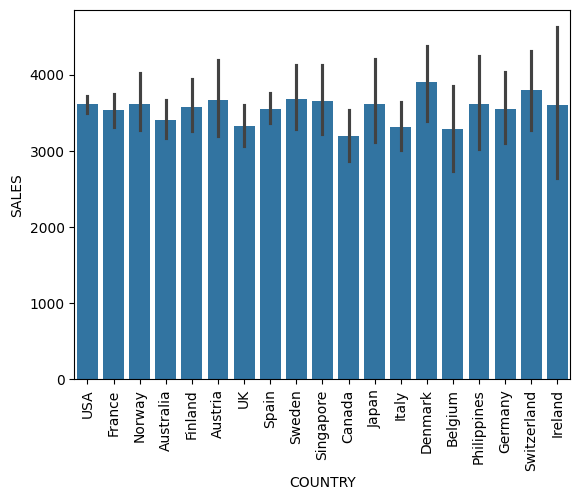

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="COUNTRY", y="SALES", data=pdf)
plt.xticks(rotation=90)
plt.show()

# Sales Distribution by Country

The bar chart above shows the distribution of sales across different countries.  
From the visualization, we can observe that sales values vary between countries, indicating differences in market demand and customer purchasing behavior.

Key observations:

- Several countries such as the **USA, Denmark, Switzerland, and Ireland** show relatively higher sales values.
- Countries like **Canada and Japan** show comparatively lower sales levels.
- The variation in sales suggests that some regions contribute more significantly to the company's revenue.

This analysis helps businesses identify high-performing markets and focus their strategies on regions with strong sales potential.

## Final Conclusion

In this task, big data analysis was performed using PySpark on a sales dataset.  
The dataset was processed and analyzed to identify key business insights.

Main findings:

- The USA generates the highest total sales among all countries.
- Classic Cars and Vintage Cars are the most profitable product lines.
- A small number of customers contribute significantly to overall revenue.
- Sales distribution varies across countries, indicating different market demands.

This analysis demonstrates how PySpark can be used for scalable big data processing and business insight generation.